# 03 · Training & Analysis

Linear regression implemented with the normal equation (as in the lessons), evaluated with RMSE.

Sections: baseline → imputation strategy → regularisation → seed stability → final test → residual analysis.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PROC = Path("../data/processed")
TARGET = "fuel_efficiency_mpg"
FEATURES = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]

df_train = pd.read_csv(PROC / "train_seed42.csv")
df_val = pd.read_csv(PROC / "val_seed42.csv")
df_test = pd.read_csv(PROC / "test_seed42.csv")
hp_mean_train = json.loads((PROC / "imputation_seed42.json").read_text())["horsepower_train_mean"]

y_train, y_val, y_test = (d[TARGET].to_numpy() for d in (df_train, df_val, df_test))
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

## Model code

In [2]:
def prepare_X(frame, fill_value=0.0):
    return frame[FEATURES].fillna(fill_value).to_numpy()


def train_linear_regression(X, y, r=0.0):
    """Normal equation with optional L2 term: w = (X'X + rI)^-1 X'y."""
    X = np.column_stack([np.ones(X.shape[0]), X])
    XTX = X.T @ X + r * np.eye(X.shape[1])
    w = np.linalg.inv(XTX) @ X.T @ y
    return w[0], w[1:]


def predict(X, w0, w):
    return w0 + X @ w


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))

## 1. Baseline (fill NaN with 0, no regularisation)

In [3]:
w0, w = train_linear_regression(prepare_X(df_train, 0), y_train)
val_rmse = rmse(y_val, predict(prepare_X(df_val, 0), w0, w))
print(f"validation RMSE: {val_rmse:.4f}")
pd.Series(w, index=FEATURES, name="weight").to_frame().assign(bias=w0)

validation RMSE: 2.2053


,weight,bias
engine_displacement,-0.001515,-153.884962
horsepower,-0.000005,-153.884962
vehicle_weight,-0.003954,-153.884962
model_year,0.102147,-153.884962


Baseline RMSE ≈ 2.2 mpg against a target std of ≈ 2.9 mpg — the four features explain a good share of
the variance, but not all of it.

## 2. Imputation strategy: 0 vs. training mean

In [4]:
results = {}
for name, fill in [("with 0", 0.0), ("with mean", hp_mean_train)]:
    w0, w = train_linear_regression(prepare_X(df_train, fill), y_train)
    results[name] = rmse(y_val, predict(prepare_X(df_val, fill), w0, w))

pd.Series(results, name="val RMSE").round(3).to_frame()

,val RMSE
with 0,2.205
with mean,2.202


Mean imputation is very slightly better (2.202 vs. 2.205). Filling with 0 tells the model "this car has
0 hp", which is far from the real distribution (~250 hp) and distorts the horsepower coefficient; the mean
keeps the imputed rows near the centre. The gap is small because only ~9 % of rows are affected.

## 3. Regularisation (fill NaN with 0)

In [5]:
rs = [0, 0.01, 0.1, 1, 5, 10, 100]
X_tr, X_va = prepare_X(df_train, 0), prepare_X(df_val, 0)

reg = pd.DataFrame({
    "r": rs,
    "val_rmse": [rmse(y_val, predict(X_va, *train_linear_regression(X_tr, y_train, r))) for r in rs],
})
reg["val_rmse"] = reg["val_rmse"].round(4)
best_r = reg.loc[reg["val_rmse"].idxmin(), "r"]  # idxmin -> first (smallest r) on ties
print("best r:", best_r)
reg

best r: 0.0


,r,val_rmse
0,0.00,2.2053
1,0.01,2.2058
2,0.10,2.2241
3,1.00,2.3492
4,5.00,2.4094
5,10.00,2.4195
6,100.00,2.4292


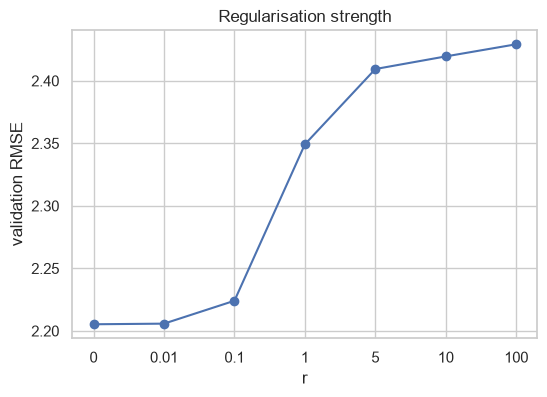

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(range(len(rs)), reg["val_rmse"], marker="o")
plt.xticks(range(len(rs)), rs)
plt.xlabel("r"); plt.ylabel("validation RMSE"); plt.title("Regularisation strength")
plt.show()

Validation RMSE only gets worse as `r` grows: the model has just four features and 6 000 training rows, so
it is not overfitting and shrinking the weights only adds bias. `r = 0` is best.

## 4. Seed stability

In [7]:
def split_dataset(df, seed):
    n = len(df); n_val = int(n * 0.2); n_test = int(n * 0.2); n_train = n - n_val - n_test
    np.random.seed(seed)
    idx = np.arange(n); np.random.shuffle(idx)
    return df.iloc[idx[:n_train]], df.iloc[idx[n_train:n_train + n_val]], df.iloc[idx[n_train + n_val:]]


# Re-split from the original file so the seed logic matches the lecture exactly.
full = pd.read_csv("../data/car_fuel_efficiency_2026.csv")[FEATURES + [TARGET]]

scores = []
for seed in range(10):
    tr, va, _ = split_dataset(full, seed)
    w0, w = train_linear_regression(prepare_X(tr, 0), tr[TARGET].to_numpy())
    scores.append(rmse(va[TARGET].to_numpy(), predict(prepare_X(va, 0), w0, w)))

seed_df = pd.DataFrame({"seed": range(10), "val_rmse": scores})
print("std:", round(np.std(scores), 3))
seed_df.round(4)

std: 0.029


,seed,val_rmse
0,0,2.2392
1,1,2.2021
2,2,2.1634
3,3,2.2044
4,4,2.2019
5,5,2.2458
6,6,2.2697
7,7,2.1908
8,8,2.2166
9,9,2.2070


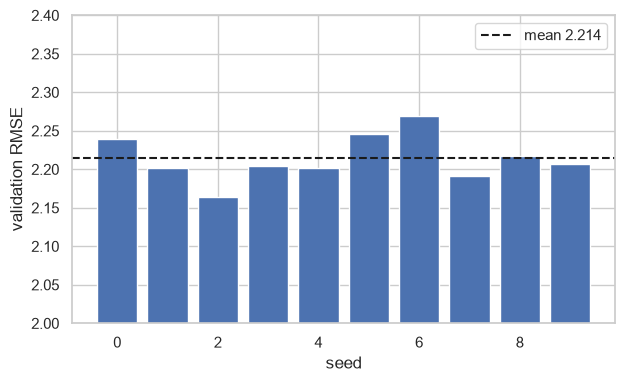

In [8]:
plt.figure(figsize=(7, 4))
plt.bar(seed_df["seed"], seed_df["val_rmse"])
plt.axhline(np.mean(scores), color="k", ls="--", label=f"mean {np.mean(scores):.3f}")
plt.ylim(2.0, 2.4); plt.xlabel("seed"); plt.ylabel("validation RMSE"); plt.legend()
plt.show()

Std ≈ 0.029: RMSE moves by a few hundredths of an mpg depending on the split — small next to the RMSE
itself (~2.2), so the model is stable. Differences of that size between two model variants should not be
over-interpreted (e.g. the 0-vs-mean gap of 0.003 is well inside this noise).

## 5. Final model on the test set

In [9]:
# Same recipe as Q6: seed 9, train+val combined, fill 0, r = 0.001
tr, va, te = split_dataset(full, 9)
tv = pd.concat([tr, va])
w0, w = train_linear_regression(prepare_X(tv, 0), tv[TARGET].to_numpy(), r=0.001)
test_pred = predict(prepare_X(te, 0), w0, w)
print(f"test RMSE (seed 9): {rmse(te[TARGET].to_numpy(), test_pred):.4f}")

test RMSE (seed 9): 2.2358


## 6. Residual analysis

seed-42 test RMSE: 2.2378   mean residual: 0.0594


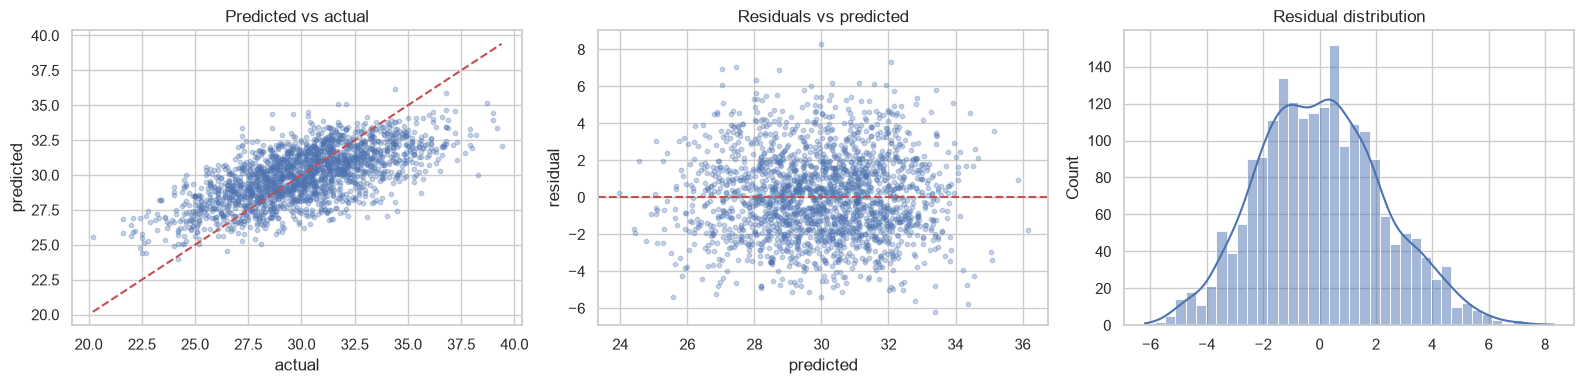

In [10]:
# Seed-42 baseline model, evaluated on the untouched test split
w0, w = train_linear_regression(prepare_X(df_train, 0), y_train)
pred = predict(prepare_X(df_test, 0), w0, w)
resid = y_test - pred
print(f"seed-42 test RMSE: {rmse(y_test, pred):.4f}   mean residual: {resid.mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(y_test, pred, alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--"); axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted"); axes[0].set_title("Predicted vs actual")
axes[1].scatter(pred, resid, alpha=0.3, s=10); axes[1].axhline(0, color="r", ls="--")
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual"); axes[1].set_title("Residuals vs predicted")
sns.histplot(resid, bins=40, kde=True, ax=axes[2]); axes[2].set_title("Residual distribution")
plt.tight_layout(); plt.show()

In [11]:
# Does the error depend on whether horsepower was missing (i.e. imputed with 0)?
was_missing = df_test["horsepower"].isna().to_numpy()
pd.DataFrame({
    "rows": [(~was_missing).sum(), was_missing.sum()],
    "RMSE": [rmse(y_test[~was_missing], pred[~was_missing]), rmse(y_test[was_missing], pred[was_missing])],
}, index=["horsepower present", "horsepower missing (filled 0)"]).round(3)

,rows,RMSE
horsepower present,1837,2.237
horsepower missing (filled 0),163,2.251


## Summary

| Experiment | Result |
|---|---|
| Imputation | mean ≥ 0 (2.202 vs 2.205), difference is tiny |
| Regularisation | none needed — `r = 0` is best on validation |
| Seed stability | std ≈ 0.029 across 10 seeds |
| Final (seed 9, r = 0.001) | test RMSE ≈ 2.236 |

**Ideas to improve on this:** add the categorical columns (`origin`, `fuel_type`, `drivetrain`), model
`horsepower` missingness explicitly, or try non-linear models (covered later in the course).